In [1]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array

In [2]:
# path to ONE image from your dataset
img_path = "dataset/train/normal/IM-0115-0001.jpeg" 
# image size
img_height = 224
img_width = 224

In [3]:
# load image
img = load_img(img_path, target_size=(img_height, img_width))
img_array = img_to_array(img)

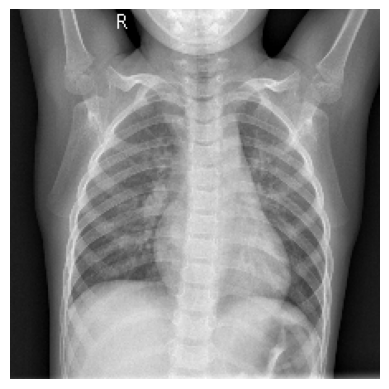

In [4]:
# display image
plt.imshow(img_array.astype("uint8"))
plt.axis("off")
plt.show()

In [5]:
# reshape for keras (1 image batch)
img_array = np.expand_dims(img_array, axis=0)

In [6]:
# define augmentation
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.15,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)

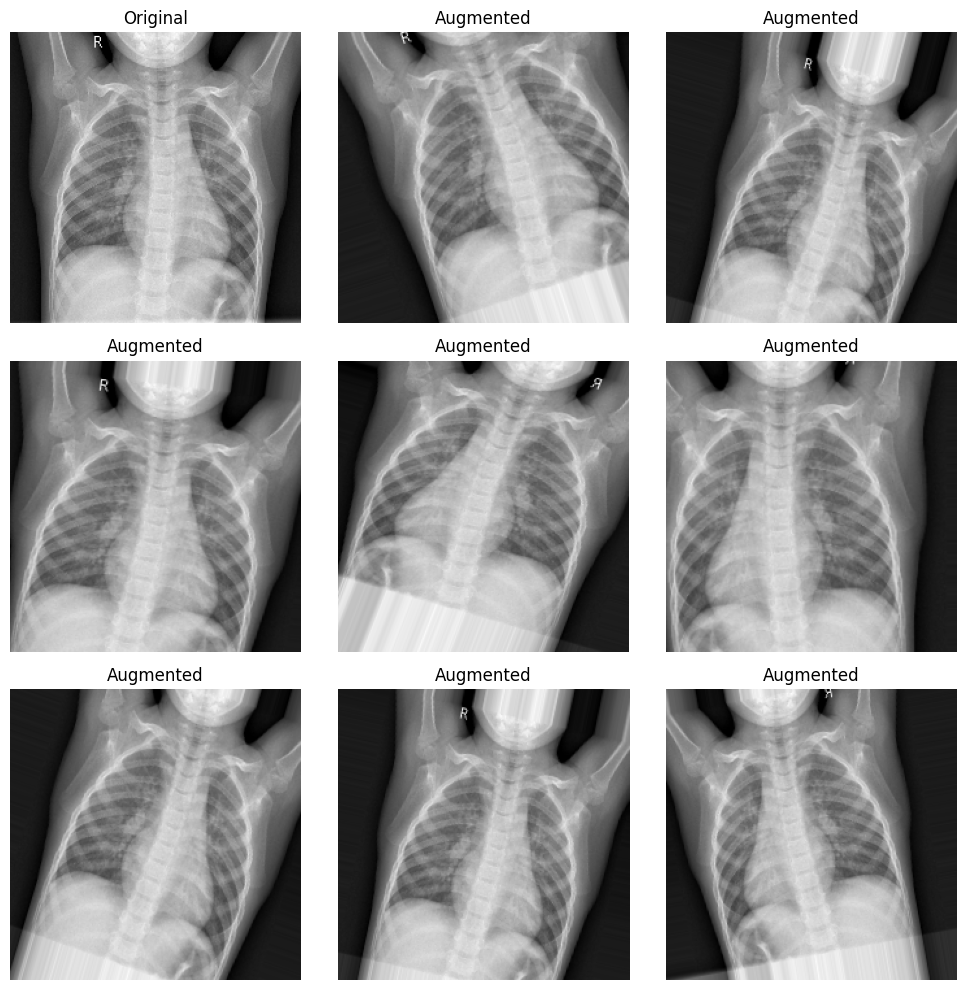

In [7]:
# plot original + augmented images
plt.figure(figsize=(10,10))

# show original image
plt.subplot(3,3,1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

# generate augmented images
i = 1
for batch in datagen.flow(img_array, batch_size=1):

    plt.subplot(3,3,i+1)
    plt.imshow(batch[0])
    plt.title("Augmented")
    plt.axis("off")

    i += 1
    
    if i > 8:   # number of augmented images
        break

plt.tight_layout()
plt.show()